In [1]:
!pip install shap

     |████████████████████████████████| 539 kB 1.1 MB/s eta 0:00:01


In [2]:
!pip install phik

     |████████████████████████████████| 686 kB 606 kB/s eta 0:00:01


In [3]:
!pip install -Uq scikit-learn #обновим тк в практикуме старая версия

In [4]:
import os
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import sklearn
import numpy as np
import phik
import shap
from scipy import stats as st

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, recall_score, precision_score, roc_auc_score, make_scorer
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.impute import SimpleImputer 
from sklearn.feature_selection import SelectKBest
from matplotlib.gridspec import GridSpec

RANDOM_STATE = 42

# Проект HR-аналитика компании «Работа с заботой»

HR-аналитики компании «Работа с заботой» помогают бизнесу оптимизировать управление персоналом: бизнес предоставляет данные, а аналитики предлагают, как избежать финансовых потерь и оттока сотрудников. В этом HR-аналитикам пригодится машинное обучение, с помощью которого получится быстрее и точнее отвечать на вопросы бизнеса.
Компания предоставила данные с характеристиками сотрудников компании. Среди них — уровень удовлетворённости сотрудника работой в компании. Эту информацию получили из форм обратной связи: сотрудники заполняют тест-опросник, и по его результатам рассчитывается доля их удовлетворённости от 0 до 1, где 0 — совершенно неудовлетворён, 1 — полностью удовлетворён. 
Собирать данные такими опросниками не так легко: компания большая, и всех сотрудников надо сначала оповестить об опросе, а затем проследить, что все его прошли. 
У вас будет несколько задач. 

* Первая — построить модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика. 
Почему бизнесу это важно: удовлетворённость работой напрямую влияет на отток сотрудников. А предсказание оттока — одна из важнейших задач HR-аналитиков. Внезапные увольнения несут в себе риски для компании, особенно если уходит важный сотрудник.
* Вторая задача — построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании.
_________________________

**Задача 1: предсказание уровня удовлетворённости сотрудника**

Для этой задачи заказчик предоставил данные с признаками:
* id — уникальный идентификатор сотрудника;
* dept — отдел, в котором работает сотрудник;
* level — уровень занимаемой должности;
* workload — уровень загруженности сотрудника;
* employment_years — длительность работы в компании (в годах);
* last_year_promo — показывает, было ли повышение за последний год;
* last_year_violations — показывает, нарушал ли сотрудник трудовой договор за последний год;
* supervisor_evaluation — оценка качества работы сотрудника, которую дал руководитель;
* salary — ежемесячная зарплата сотрудника;
* job_satisfaction_rate — уровень удовлетворённости сотрудника работой в компании, целевой признак.

***Шаг 1. Загрузка данных***
Загрузите файлы с данными:

Тренировочная выборка: train_job_satisfaction_rate.csv

Входные признаки тестовой выборки: test_features.csv

Целевой признак тестовой выборки: test_target_job_satisfaction_rate.csv

***Шаг 2. Предобработка данных***
Изучите данные и сделайте выводы. При необходимости выполните предобработку. Если есть пропуски, заполните их в пайплайне.

***Шаг 3. Исследовательский анализ данных***
Исследуйте все признаки и сделайте выводы о том, как их нужно подготовить.

***Шаг 4. Подготовка данных***
Подготовку признаков выполните в пайплайне, дополнив пайплайн шагом предобработки. При кодировании учитывайте особенности признаков и моделей и используйте как минимум два кодировщика.

***Шаг 5. Обучение моделей***
Обучите как минимум две модели. Возьмите одну линейную модель, а в качестве второй — дерево решений. Подберите гиперпараметры как минимум для одной модели с помощью одного из известных вам инструментов.
Выберите лучшую модель и проверьте её качество. Выбор делайте на основе новой метрики — SMAPE (англ. symmetric mean absolute percentage error, «симметричное среднее абсолютное процентное отклонение»). 

Напишите функцию, которая принимает на вход массивы NumPy или объекты Series в pandas и возвращает значение метрики SMAPE. Используйте эту метрику при подборе гиперпараметров и оценке качества моделей. 
В решении сохраните работу со всеми моделями, которые вы пробовали. Сделайте выводы.

***Шаг 6. Оформление выводов***
Сделайте промежуточные выводы о том, какая модель справилась лучше и почему.

___________________________________

**Задача 2: предсказание увольнения сотрудника из компании**

Для этой задачи вы можете использовать те же входные признаки, что и в предыдущей задаче. Однако целевой признак отличается: это quit — увольнение сотрудника из компании.

***Шаг 1. Загрузка данных***
Загрузите данные из файлов:

Тренировочная выборка: train_quit.csv

Входные признаки тестовой выборки те же, что и в прошлой задаче: test_features.csv

Целевой признак тестовой выборки: test_target_quit.csv

***Шаг 2. Предобработка данных***
Изучите данные и при необходимости выполните предобработку. Если есть пропуски, заполните их в пайплайне.

***Шаг 3. Исследовательский анализ данных***

    3.1. Проведите исследовательский анализ данных.

    3.2. Составьте портрет «уволившегося сотрудника». Например, можно узнать, в каком отделе с большей вероятностью работает уволившийся сотрудник и какой у него уровень загруженности. Также можно сравнить среднее значение зарплаты ушедших сотрудников с теми, кто остался в компании.

    3.3. Аналитики утверждают, что уровень удовлетворённости сотрудника работой в компании влияет на то, уволится ли сотрудник. Проверьте это утверждение: визуализируйте и сравните распределения признака job_satisfaction_rate для ушедших и оставшихся сотрудников. Используйте данные с обоими целевыми признаками тестовой выборки.

***Шаг 4. Добавление нового входного признака***
Допустим, job_satisfaction_rate и quit действительно связаны и вы получили необходимое значение метрики в первой задаче. Тогда добавьте job_satisfaction_rate, предсказанный лучшей моделью первой задачи, к входным признакам второй задачи.

***Шаг 5. Подготовка данных***
Подготовьте признаки так же, как и в первой задаче: выполните подготовку в пайплайне, дополнив пайплайн предобработки. При кодировании учитывайте особенности признаков и моделей и используйте как минимум два кодировщика.

***Шаг 6. Обучение модели***
Обучите как минимум три модели. Как минимум для двух из них подберите гиперпараметры. Проверьте качество лучшей модели.

Метрика оценки качества в этой задаче — ROC-AUC. Критерий успеха: ROC-AUC≥0.91 на тестовой выборке. 

Напомним: отбор признаков часто помогает улучшить метрику.

***Шаг 7. Выводы***
* Сделайте промежуточные выводы о том, какая модель справилась лучше и почему.
* Общий вывод
* Сформулируйте общий вывод:
* опишите задачу;
* опишите все этапы работы;
* добавьте выводы и дополнительные предложения для бизнеса.

# Задача 1: предсказание уровня удовлетворённости сотрудника

## ***Шаг 1. Загрузка данных***
Загрузите файлы с данными:

Тренировочная выборка: train_job_satisfaction_rate.csv

Входные признаки тестовой выборки: test_features.csv

Целевой признак тестовой выборки: test_target_job_satisfaction_rate.csv

In [5]:
try:
    train = pd.read_csv('train_job_satisfaction_rate.csv')
    X_test = pd.read_csv('test_features.csv')
    y_test = pd.read_csv('test_target_job_satisfaction_rate.csv')
except:
    train = pd.read_csv('/datasets/train_job_satisfaction_rate.csv')
    X_test = pd.read_csv('/datasets/test_features.csv')
    y_test = pd.read_csv('/datasets/test_target_job_satisfaction_rate.csv')

In [6]:
train.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


<font color='blue'><b>Комментарий ревьюера: </b></font> ⚠️\
<font color='darkorange'>При считывании данных из файла здорово перестраховывать себя от ошибок, связанных, например, с неверным указанием пути к файлу. А иногда бывает, что работаешь с файлом локально, выгружаешь его на сервер, ожидая, что он будет принимать данные, которые лежат на том же сервере, а код падает с ошибкой, потому что путь к файлу не поменялся с локального на серверный.
    
Для этого, например, можно использовать конструкцию `try-except`: сначала пробуешь локальный путь, при возникновении ошибки используется серверный путь (подробнее можешь почитать тут: https://pythonworld.ru/tipy-dannyx-v-python/isklyucheniya-v-python-konstrukciya-try-except-dlya-obrabotki-isklyuchenij.html).
    
Но еще лучше использовать библиотеку `os` - её использование позволит тебе проверять существование указанных директорий (что может быть актуально при одновременной работа на локальном и сетевом окружении) и загружать данные из существующей директории, избегая ошибок. Как пример:
```python    
    import os

    pth1 = '/folder_1/data.csv'
    pth2 = '/folder_2/data.csv'
    
    if os.path.exists(pth1):
        query_1 = pd.read_csv(pth1)
    elif os.path.exists(pth2):
        query_1 = pd.read_csv(pth2)
    else:
        print('Something is wrong')
```
Так же, данные Практикума можно загружать напрямую с базы:\
`data = pd.read_csv('https://code.s3.yandex.net/datasets/имя_файла.csv')`</font>

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


In [8]:
X_test.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


In [9]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB


In [10]:
y_test.head()

,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


In [11]:
y_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


Промежуточный вывод:

* в таблицах train и X_test есть пропуски в столбцах 'dept' и 'level'. Обратим на пропуски внимание более детально на следующих этапах;

* также на следующем этапы надо проверить наличие дубликатов как явных так и неявных;

* типы данных определны верно;

* названия колонок уже приведены к змеиному формату;

* в таблица X_test и y_test не совпадает порядок 'id'. Нужно исправить, по возможности. 

## ***Шаг 2. Предобработка данных***

Изучите данные и сделайте выводы. При необходимости выполните предобработку. Если есть пропуски, заполните их в пайплайне.

In [12]:
datasets = [train, X_test, y_test]

for name in datasets:
    print(name.duplicated().sum())
#полных дубликатов не обнаружено

0
0
0


In [13]:
#отсортируем по 'id' чтобы сделать совпадения с целевым принзаком из y_test
X_test = X_test.sort_values(by='id').reset_index(drop=True)
X_test.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,100298,hr,junior,low,2,no,no,4,19200
1,100480,marketing,junior,low,4,no,no,4,16800
2,100503,purchasing,middle,high,5,no,no,4,55200
3,100610,sales,middle,medium,5,no,no,4,43200
4,100692,sales,middle,high,6,no,no,4,48000


In [14]:
#теперь сортируем целевой признак
y_test = y_test.sort_values(by='id').reset_index(drop=True)
y_test.head()

,id,job_satisfaction_rate
0,100298,0.80
1,100480,0.84
2,100503,0.79
3,100610,0.75
4,100692,0.69


In [15]:
X_test.columns

Index(['id', 'dept', 'level', 'workload', 'employment_years',
       'last_year_promo', 'last_year_violations', 'supervisor_evaluation',
       'salary'],
      dtype='object')

In [16]:
#вручную просматриваем данные на наличие опечаток или неявных дублей
train['level'].value_counts()

junior    1894
middle    1744
sinior     358
Name: level, dtype: int64

Сохраним такой формат входных и целевого признака из тестовых данных.
Неявные дубликаты в данных отсутсвуют. 
Опечатка level = 'sinior' указана во всех таблицах, ее можно не убирать. 

***Шаг 3. Исследовательский анализ данных***

Исследуйте все признаки и сделайте выводы о том, как их нужно подготовить.


In [17]:
train.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


In [18]:
column_file = ['salary', 'job_satisfaction_rate']

In [19]:
#создание функции для построения гистограммы и диаграммы размаха для столбцов с количественными признаками
def hist_box(data, column):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.xlabel(f'Значения столбца "{column}"')
    plt.ylabel('Частота')
    plt.title(f'Гистограмма для "{column}"')
    sns.histplot(data[column], color='Green')
    plt.subplot(1, 2, 2)
    plt.xlabel(f'Значения столбца {column}')
    plt.title(f'Диаграмма размаха для {column}')
    sns.boxplot(x=data[column], color='Orange')

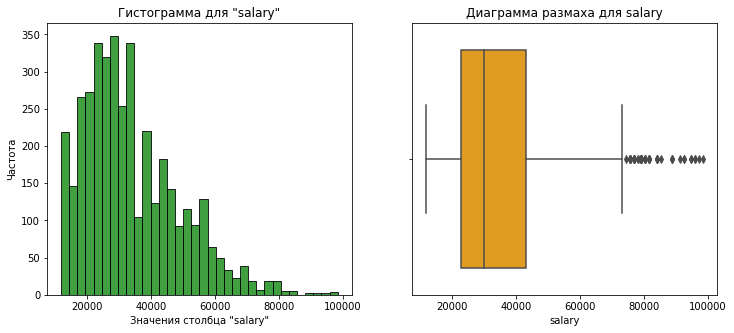

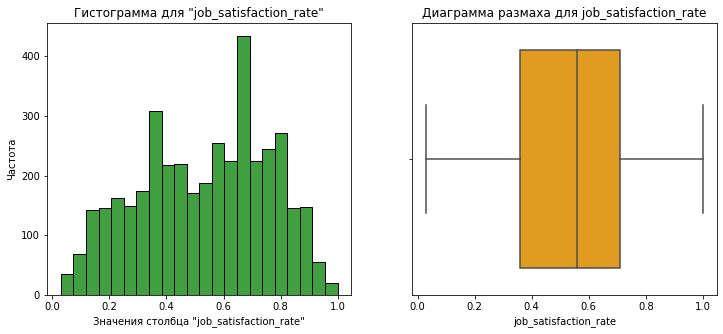

In [20]:
#построение распределений
for name in column_file:
    hist_box(train, name)

* salary имеет смещенное влево распределение и немного аномально больших значенияй;
* job_satisfaction_rate имеет распределение похожее на нормальное без выбросов.

In [21]:
categ_col = ['dept', 
             'level', 
             'workload', 
             'employment_years', 
             'last_year_promo', 
             'last_year_violations',
             'supervisor_evaluation']

In [22]:
def count_box(data, column):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.xlabel(f'Значения столбца "{column}"')
    plt.ylabel('Частота')
    plt.title(f'График распределения для "{column}"')
    sns.countplot(x=data[column], data=data);

**Таблица train:**

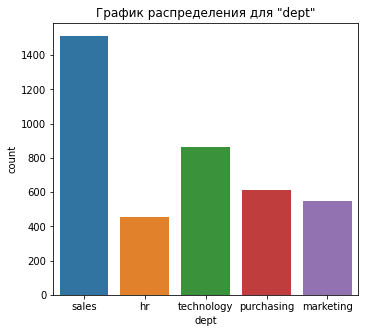

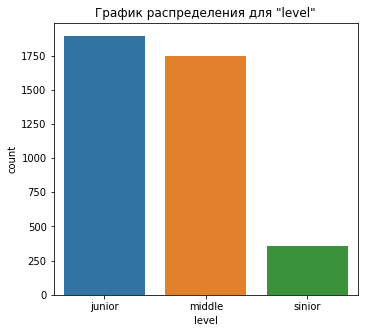

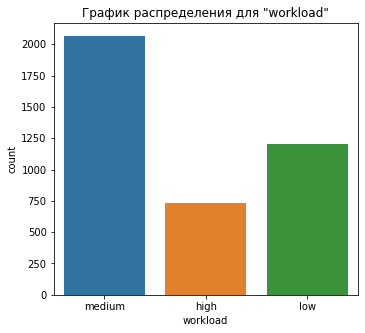

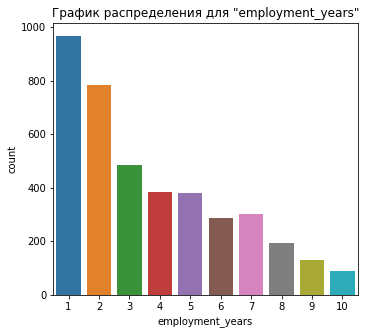

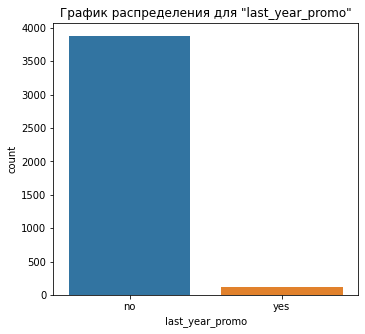

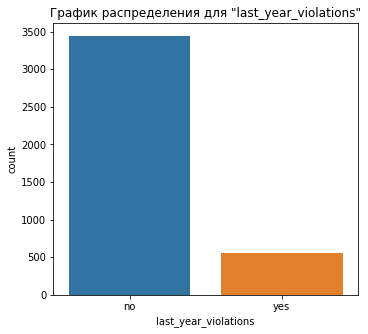

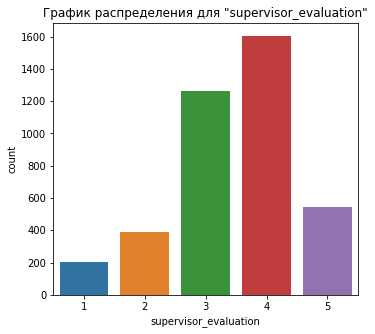

In [23]:
for name in categ_col:
    count_box(train, name)

* признаки несбаласированны;
* необычных значений в признаках не наблюдается.

In [24]:
train.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


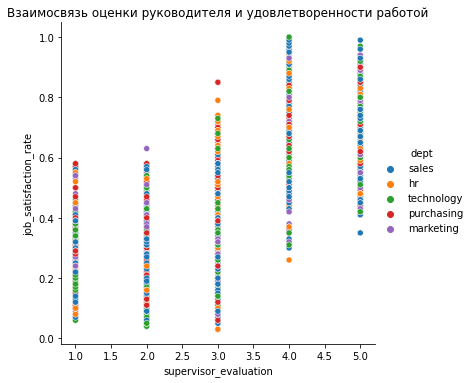

In [25]:
sns.relplot(x='supervisor_evaluation', 
            y='job_satisfaction_rate', 
            data=train, 
            kind='scatter', 
           hue='dept')
plt.title('Взаимосвязь оценки руководителя и удовлетворенности работой');

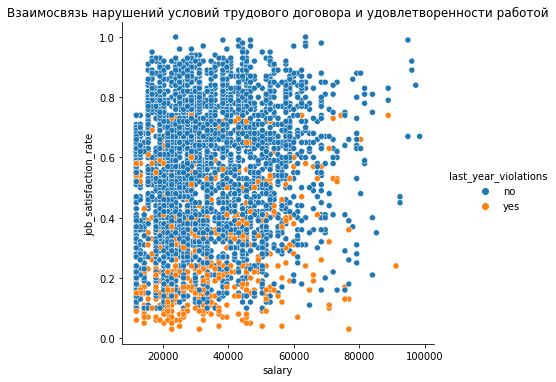

In [26]:
sns.relplot(x='salary', 
            y='job_satisfaction_rate', 
            data=train, 
            kind='scatter', 
           hue='last_year_violations')
plt.title('Взаимосвязь нарушений условий трудового договора и удовлетворенности работой');

**Зависимость всех критериев наглядно отобразим в виде матрицы:**

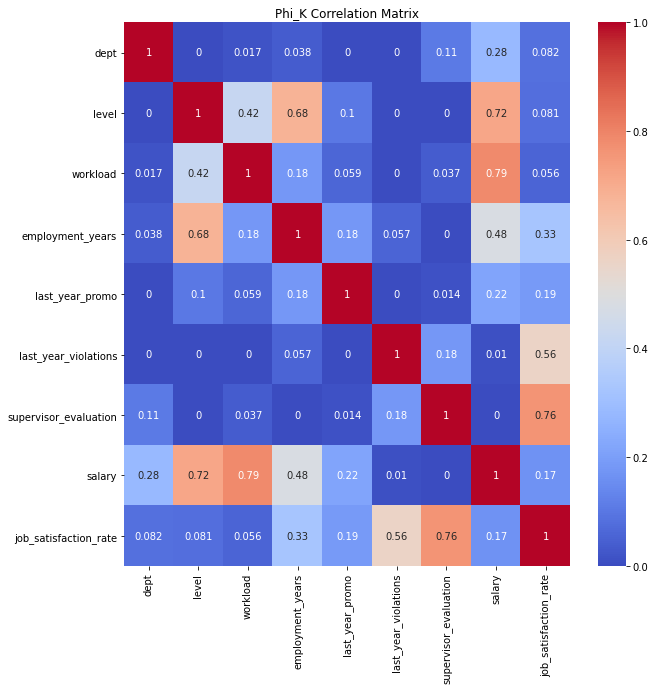

In [27]:
#вычисление матрицы корреляции
corr_matrix = train.drop(['id'], axis=1).phik_matrix(interval_cols=['salary', 
                                                                   'job_satisfaction_rate'])


#визуализация матрицы корреляции 
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Phi_K Correlation Matrix');

***Промежуточные выводы и наблюдения:***

Обнаружена высокая корреляция между:

* уровнем занимаемой должности и длительностью работы в компании;
* уровнем занимаемой должности и зарплатой;
* уровнем загруженности сотрудника и зарплатой.

При этом, корреляция не настолько высока, чтобы не включать эти признаки в модель машинного обучения. Пробуем оставить все как есть.


* salary имеет смещенное влево распределение и немного аномально больших значенияй;
* job_satisfaction_rate имеет распределение похожее на нормальное без выбросов;
* признаки несбаласированны;
* необычных значений в признаках не наблюдается;
* чем выше работодатель оцеенил работу, тем выше и удовлетворенность самого работника;
* основная масса работников, допускавших нарушение трудовго договора низко оценивают удовлетворенность работой;
* работники, не нарушавшие условия трудового договора, удовлетворены работой по мере роста зарплаты.


**Также проведем анализ тестовых данных X_test и посмотрим насколько они похожи на обучающие**

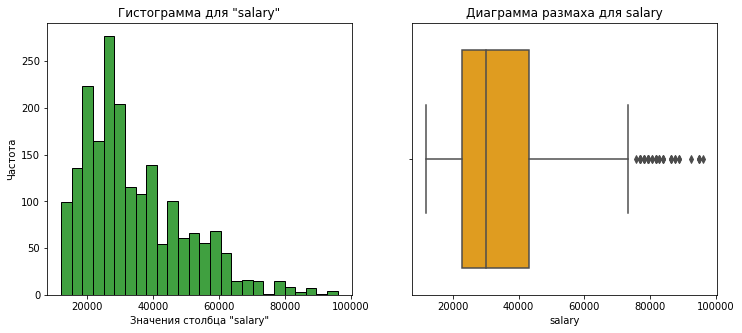

In [28]:
#построение распределений для X_test
column_file_X_test = ['salary']


for name in column_file_X_test:
    hist_box(X_test, name)

In [29]:
categ_col_X_test = ['dept', 
             'level', 
             'workload', 
             'employment_years', 
             'last_year_promo', 
             'last_year_violations',
             'supervisor_evaluation']

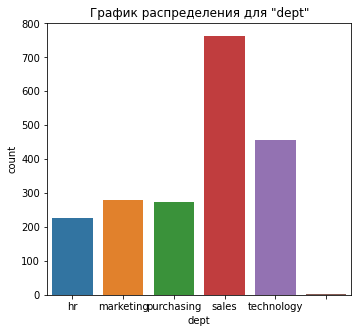

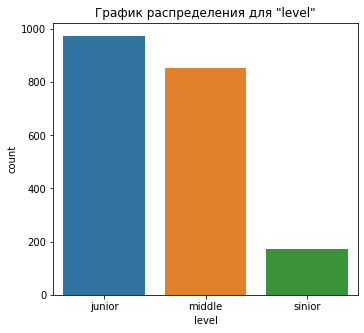

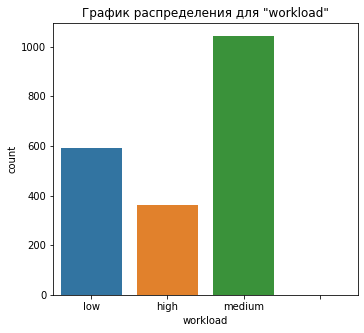

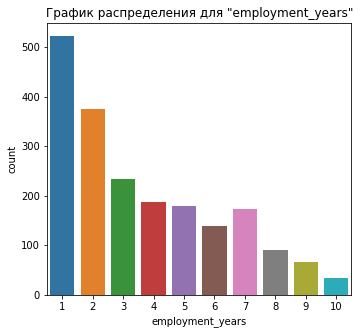

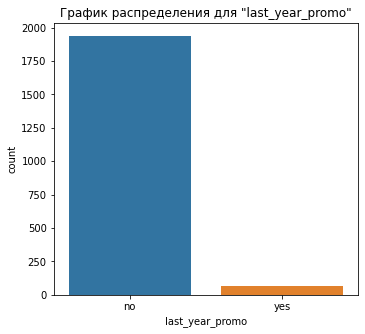

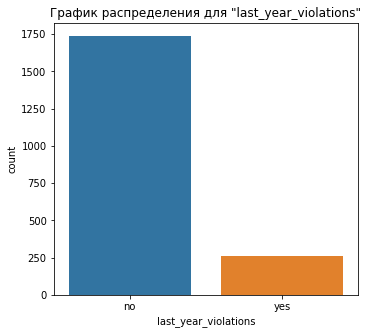

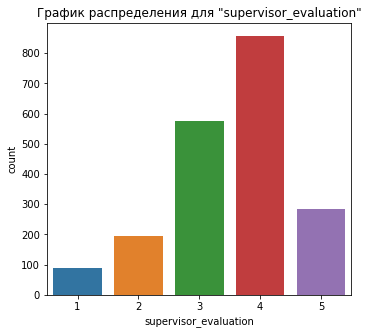

In [30]:
for name in categ_col_X_test:
    count_box(X_test, name)

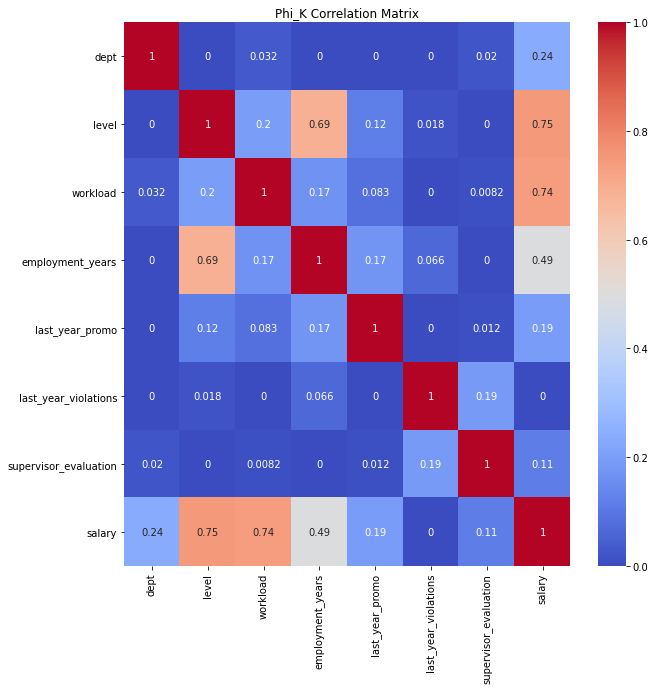

In [31]:
#вычисление матрицы корреляции
corr_matrix = X_test.drop(['id'], axis=1).phik_matrix(interval_cols=['salary'])


#визуализация матрицы корреляции 
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Phi_K Correlation Matrix');

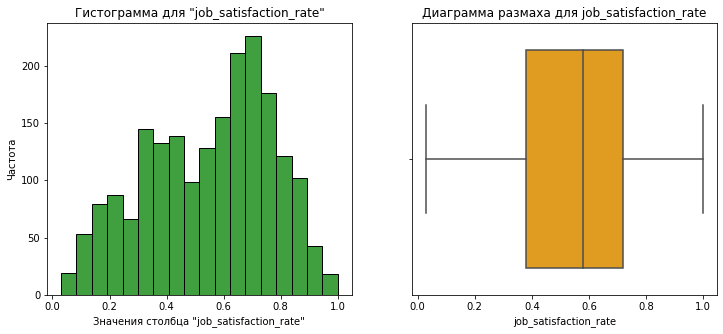

In [32]:
#Также посмотрим распределение целевого признака тестовой выборки
hist_box(y_test, 'job_satisfaction_rate')

Тестовые данные имеют сильно похожи (почти идентичные распределения) с тренировочными, корреляции недостаточно высоки чтобы удальть часть признаков, рациональней поступить как и тренировочными данными - оставить как есть. 

## ***Шаг 4. Подготовка данных***

Подготовку признаков выполните в пайплайне, дополнив пайплайн шагом предобработки. При кодировании учитывайте особенности признаков и моделей и используйте как минимум два кодировщика.
_________________

Целевой признак 'job_satisfaction_rate' является непрерывной числовой переменной, следовательно будем решать эту задачу методом регресии, а точнее линейной регрессией, деревом решений и регрессией случайного леса.

In [33]:
#создание списков количественных и категориальных
num_col = ['employment_years', 
           'supervisor_evaluation', 
           'salary']

ord_col = ['level',
           'workload']

ohe_col = ['dept',
           'last_year_promo', 
           'last_year_violations']

In [34]:
data_1 = train.drop('id', axis=1)

data_1.duplicated().sum()

245

In [35]:
data_1 = data_1.drop_duplicates()

In [36]:
# создание тренировочной выборки входных признаков и целевого признака
X_train = data_1.drop('job_satisfaction_rate', axis=1)
y_train = data_1['job_satisfaction_rate']
X_test = X_test.drop('id', axis=1)
y_test = y_test['job_satisfaction_rate']

In [37]:
# Создание трансформеров для числовых и категориальных признаков
ohe_pipe = Pipeline(
    [
        ('simpleImputer_ohe', 
         SimpleImputer(missing_values=np.nan, 
                       strategy='most_frequent')), #заполняем пустоты модой для всех категорий
       ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
)
#Pipeline для кодирования категориальных ранговых признаков
ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')), 
     ('ord', OrdinalEncoder(
    categories=[
        ['junior', 'middle', 'senior'], 
        ['low', 'medium', 'high'],
    ], 
    handle_unknown='use_encoded_value', unknown_value=-1  # np.nan заменен на -1
)),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

# Объединение трансформеров
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_col),
        ('ord', ord_pipe, ord_col),
        ('num', StandardScaler(), num_col)
    ], 
    remainder='passthrough'
)

pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeRegressor(random_state=RANDOM_STATE))
])

#Параметры для передачи GridSearchCV для поиска оптимальной модели 
#с разными Scaler и Encoder и перебором гиперпараметров

param_distributions = [
    {
        'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 21),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    {
        'models': [LinearRegression()],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    }, 
    {
        'models': [RandomForestRegressor(random_state=RANDOM_STATE)],
        'models__n_estimators': range(50, 300, 50),  # Количество деревьев
        'models__max_depth': range(2, 21),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
]

## ***Шаг 5. Обучение моделей***

Обучите как минимум две модели. Возьмите одну линейную модель, а в качестве второй — дерево решений. Подберите гиперпараметры как минимум для одной модели с помощью одного из известных вам инструментов.
Выберите лучшую модель и проверьте её качество. Выбор делайте на основе новой метрики — SMAPE (англ. symmetric mean absolute percentage error, «симметричное среднее абсолютное процентное отклонение»). 

Критерий успеха: SMAPE ≤15 на тестовой выборке.

Напишите функцию, которая принимает на вход массивы NumPy или объекты Series в pandas и возвращает значение метрики SMAPE. Используйте эту метрику при подборе гиперпараметров и оценке качества моделей. 
В решении сохраните работу со всеми моделями, которые вы пробовали. Сделайте выводы.

In [38]:
# создание собственной метрики для оценки модели

def SMAPE(y_true, y_pred):
    return 100 / len(y_true) * np.sum(2 * np.abs(y_true - y_pred) / ((np.abs(y_true) + np.abs(y_pred))))
                                      
SMAPE_score = make_scorer(SMAPE, greater_is_better=False)

In [39]:
#поиск оптимальной модели с перебором гиперпараметров (поскольку строк относительно немного будем перебирать все)
grid = GridSearchCV(
    pipe_final, 
    param_grid=param_distributions, 
    cv=5, 
    scoring=SMAPE_score, 
    n_jobs=-1, 
)

#обучение модели на тренировочной выборке
grid.fit(X_train, y_train);

In [40]:
print('Метрика SMAPE для лучшей модели:\n', round(-grid.best_score_, 2)) 
print('\nЛучшая модель и её параметры:\n\n', grid.best_params_) 

Метрика SMAPE для лучшей модели:
 13.7

Лучшая модель и её параметры:

 {'models': RandomForestRegressor(random_state=42), 'models__max_depth': 14, 'models__n_estimators': 250, 'preprocessor__num': MinMaxScaler()}


***Применим к X_test_main, нужно только убрать колонку с 'id'***

In [41]:
y_pred = grid.predict(X_test)
y_true = y_test
print(f'Метрика SMAPE на тестовой выборке: {round(SMAPE(y_true, y_pred), 2)}')

Метрика SMAPE на тестовой выборке: 12.37


/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [42]:
# Создание DataFrame с результатами кросс-валидации
results_df = pd.DataFrame(grid.cv_results_)

# Отсортируем результаты по убыванию метрики SMAPE_score
sorted_results = results_df.sort_values(by='mean_test_score', ascending=False)

# Выводим топ-5 лучших моделей
print('Топ-5 моделей по метрике SMAPE:')

# Установка опции для отображения максимальной ширины столбца
pd.set_option('display.max_colwidth', None)
display(sorted_results[['params', 'mean_test_score']].head(10))

Топ-5 моделей по метрике SMAPE:


,params,mean_test_score
253,"{'models': RandomForestRegressor(random_state=42), 'models__max_depth': 14, 'models__n_estimators': 250, 'preprocessor__num': MinMaxScaler()}",-13.696718
268,"{'models': RandomForestRegressor(random_state=42), 'models__max_depth': 15, 'models__n_estimators': 250, 'preprocessor__num': MinMaxScaler()}",-13.699383
247,"{'models': RandomForestRegressor(random_state=42), 'models__max_depth': 14, 'models__n_estimators': 150, 'preprocessor__num': MinMaxScaler()}",-13.707012
250,"{'models': RandomForestRegressor(random_state=42), 'models__max_depth': 14, 'models__n_estimators': 200, 'preprocessor__num': MinMaxScaler()}",-13.708991
244,"{'models': RandomForestRegressor(random_state=42), 'models__max_depth': 14, 'models__n_estimators': 100, 'preprocessor__num': MinMaxScaler()}",-13.716736
262,"{'models': RandomForestRegressor(random_state=42), 'models__max_depth': 15, 'models__n_estimators': 150, 'preprocessor__num': MinMaxScaler()}",-13.716988
265,"{'models': RandomForestRegressor(random_state=42), 'models__max_depth': 15, 'models__n_estimators': 200, 'preprocessor__num': MinMaxScaler()}",-13.717169
283,"{'models': RandomForestRegressor(random_state=42), 'models__max_depth': 16, 'models__n_estimators': 250, 'preprocessor__num': MinMaxScaler()}",-13.723179
254,"{'models': RandomForestRegressor(random_state=42), 'models__max_depth': 14, 'models__n_estimators': 250, 'preprocessor__num': 'passthrough'}",-13.726655
269,"{'models': RandomForestRegressor(random_state=42), 'models__max_depth': 15, 'models__n_estimators': 250, 'preprocessor__num': 'passthrough'}",-13.729406


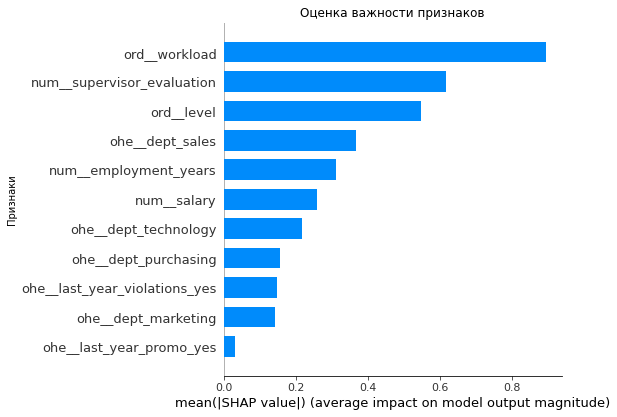

In [43]:
#поиск важных признаков
X_encoded = grid.best_estimator_['preprocessor'].fit_transform(X_train)

model = grid.best_estimator_['models'].fit(X_encoded, y_train)
explainer = shap.PermutationExplainer(model, X_encoded)


labels = grid.best_estimator_[:-1].get_feature_names_out()

plt.title('Оценка важности признаков')
plt.ylabel('Признаки')
shap.summary_plot(X_encoded, plot_type='bar', feature_names=labels) 

Самым важным признаком оказалсь нагрузка.

***Шаг 6. Оформление выводов***

Сделайте промежуточные выводы о том, какая модель справилась лучше и почему.
____________________

Лучшей оказалась модель RandomForestRegressor 250 деревьев в ансамбле с глубиной каждого дерева 14. C предобработкой MinMaxScaler(). 

Метрика SMAPE на тестовой выборке: 12.38;

Самым важным признаком оказалсь нагрузка.

Вероятно линейная линейна регрессия не стала лыше по причине наличия нелинейных зависимостей, а дерево решений не дает такой точности как мы получили в моделе случайного леса. Однако, если будет данных еще больше, то текущая модель будет требовать намного больше ресурсов для вычислений.

# Задача 2: предсказание увольнения сотрудника из компании

Для этой задачи вы можете использовать те же входные признаки, что и в предыдущей задаче. Однако целевой признак отличается: это quit — увольнение сотрудника из компании.

## ***Шаг 1. Загрузка данных***

Загрузите данные из файлов:

Тренировочная выборка: train_quit.csv

Входные признаки тестовой выборки те же, что и в прошлой задаче: test_features.csv

Целевой признак тестовой выборки: test_target_quit.csv

In [55]:
try:
    train_quit = pd.read_csv('train_quit.csv')
    y_test1 = pd.read_csv('test_target_quit.csv')
    X_test1 = pd.read_csv('test_features.csv')
except:
    train_quit = pd.read_csv('/datasets/train_quit.csv')
    y_test1 = pd.read_csv('/datasets/test_target_quit.csv')
    X_test1 = pd.read_csv('/datasets/test_features.csv')

In [56]:
train_quit.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


In [57]:
train_quit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB


In [58]:
y_test1.head()

,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


In [59]:
y_test1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB


* в таблице train_quit пропуски отсутсвуют;
* в таблицах train_quit и y_test1 не совпадает порядок 'id';
* типы данных во всех столбцах распознаны верно;
* названия столбцов написаны по "змеиным" правилам;
* необходимо проверить данные на явные и неявные дубликаты;

## ***Шаг 2. Предобработка данных***
Изучите данные и при необходимости выполните предобработку. Если есть пропуски, заполните их в пайплайне.


In [60]:
#поиск дубликатов
datasets = [train_quit, y_test1] #список датасетов

for name in datasets:
    print(name.duplicated().sum())

0
0


Явные дубликаты отсутствуют. X_test обрабатывали ранее и там дубликаты отсутствую также.
_____

Отсортируем целевые признаки как в первой задаче данные по 'id', при этом X_test уже отсортирован и не содержит колонку 'id', но для проверки откроем его заново и обработаем как и в первой задаче, но id удалять пока не будем. Назовем X_test1

In [61]:
y_test1 = y_test1.sort_values(by='id').reset_index(drop=True)
y_test1.head()

,id,quit
0,100298,no
1,100480,no
2,100503,no
3,100610,no
4,100692,no


In [62]:
y_test1.shape

(2000, 2)

In [63]:
X_test1 = X_test1.sort_values(by='id').reset_index(drop=True)
X_test1.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,100298,hr,junior,low,2,no,no,4,19200
1,100480,marketing,junior,low,4,no,no,4,16800
2,100503,purchasing,middle,high,5,no,no,4,55200
3,100610,sales,middle,medium,5,no,no,4,43200
4,100692,sales,middle,high,6,no,no,4,48000


In [64]:
X_test1.shape

(2000, 9)

Теперь 'id' y_test1 и X_test1 соответствуют.

## ***Шаг 3. Исследовательский анализ данных***

    3.1. Проведите исследовательский анализ данных.

    3.2. Составьте портрет «уволившегося сотрудника». Например, можно узнать, в каком отделе с большей вероятностью работает уволившийся сотрудник и какой у него уровень загруженности. Также можно сравнить среднее значение зарплаты ушедших сотрудников с теми, кто остался в компании.

    3.3. Аналитики утверждают, что уровень удовлетворённости сотрудника работой в компании влияет на то, уволится ли сотрудник. Проверьте это утверждение: визуализируйте и сравните распределения признака job_satisfaction_rate для ушедших и оставшихся сотрудников. Используйте данные с обоими целевыми признаками тестовой выборки.


In [65]:
train_quit.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


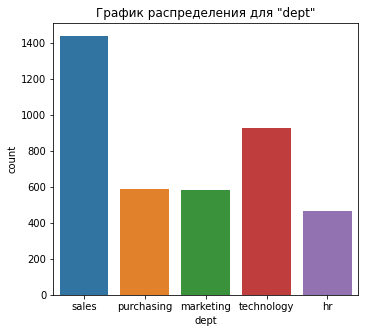

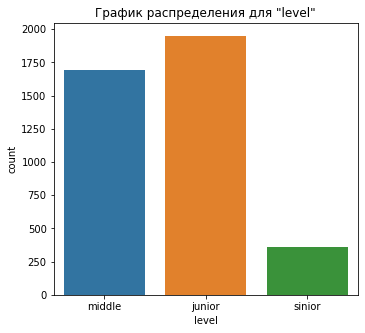

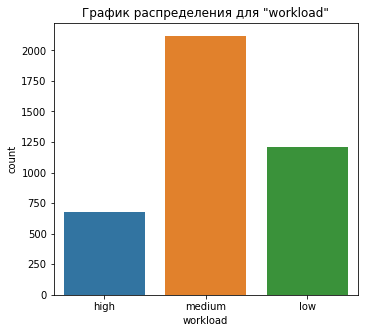

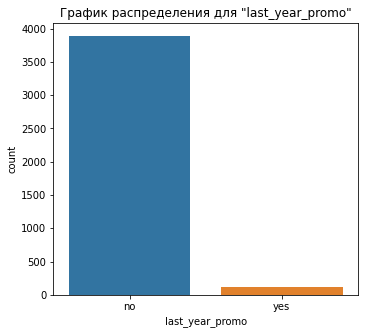

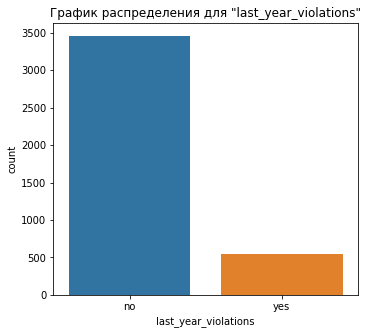

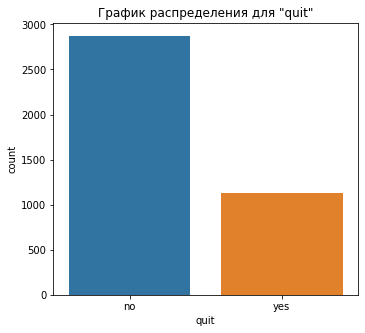

In [66]:
categ_col1 =['dept', 
             'level', 
             'workload',
             'last_year_promo',
             'last_year_violations',
             'quit']


for name in categ_col1:
    count_box(train_quit, name)

* категориальные признаки несбаласированны;
* необычных значений в признаках не наблюдается;
* на этапе подготовки признаков для обучения их необходимо будет закодировать.

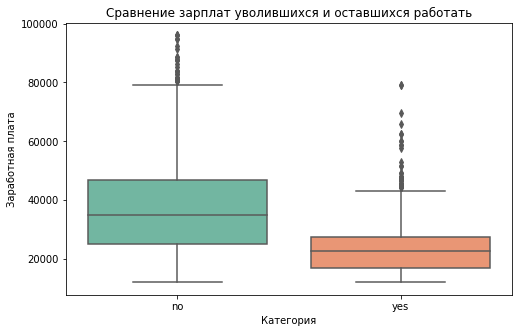

In [67]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=train_quit, x='quit', y='salary', palette='Set2')
plt.title("Сравнение зарплат уволившихся и оставшихся работать")
plt.xlabel("Категория")
plt.ylabel("Заработная плата")
plt.show()

Медианный уровень заработной платы уволившихся работников был ниже, вероятно, это и стало причиной увольнения

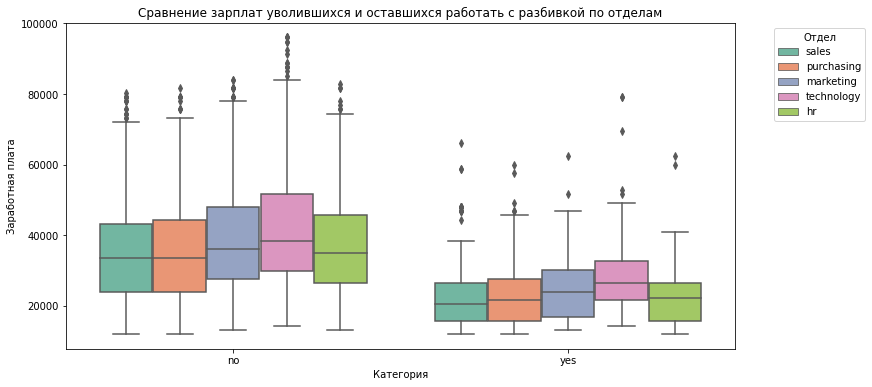

In [68]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_quit, x='quit', y='salary', hue='dept', palette='Set2')
plt.title("Сравнение зарплат уволившихся и оставшихся работать с разбивкой по отделам")
plt.xlabel("Категория")
plt.ylabel("Заработная плата")
plt.legend(title="Отдел", bbox_to_anchor=(1.05, 1), loc='upper left')  # Вынос легенды за пределы графика
plt.show()

В разбике по подразделениям ситуация аналогична - во всех отделах медианная зарплата уволившихся ниже, чем у оставшихся;

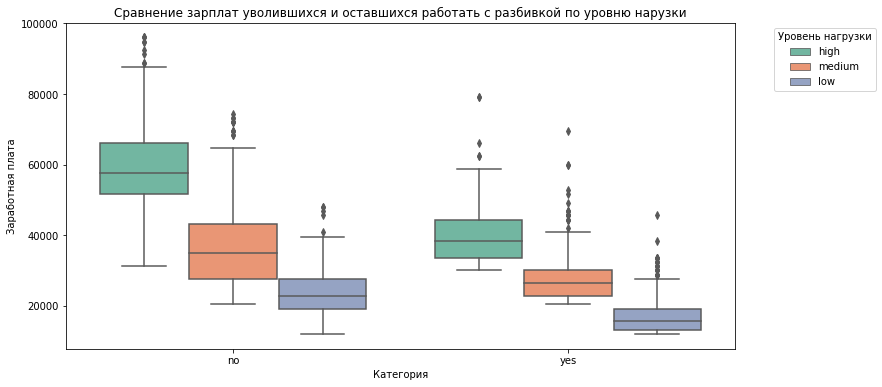

In [69]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_quit, x='quit', y='salary', hue='workload', palette='Set2')
plt.title("Сравнение зарплат уволившихся и оставшихся работать с разбивкой по уровню нарузки")
plt.xlabel("Категория")
plt.ylabel("Заработная плата")
plt.legend(title="Уровень нагрузки", bbox_to_anchor=(1.05, 1), loc='upper left')  # Вынос легенды за пределы графика
plt.show()

Уровень нагрузки у уволившихся был ниже

In [70]:
df = train_quit.groupby(['dept'])['quit'].value_counts(normalize=True)
df.loc[df.index.get_level_values(1) == 'yes']

dept        quit
hr          yes     0.250000
marketing   yes     0.280069
purchasing  yes     0.282313
sales       yes     0.283032
technology  yes     0.297414
Name: quit, dtype: float64

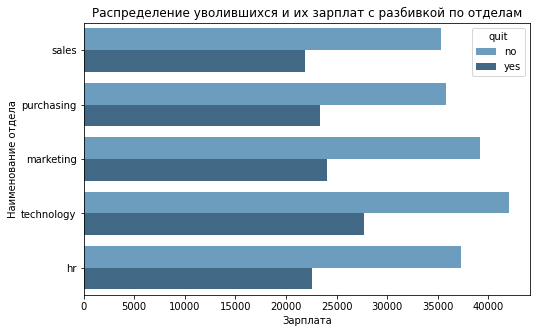

In [71]:
plt.figure(figsize=(8, 5))
sns.barplot(data=train_quit, x='salary', y='dept', ci=None, hue='quit', palette='Blues_d')
plt.title("Распределение уволившихся и их зарплат с разбивкой по отделам")
plt.xlabel("Зарплата")
plt.ylabel("Наименование отдела")
plt.show()

Отдел технологий обладает самой высокой текучкой кадров, при этом имея высокие зарплаты

Уволились только работники с низкой заработной платой по всем сферам деятельности

Работники с высокой заработной платой по своему направлению не увольнялись

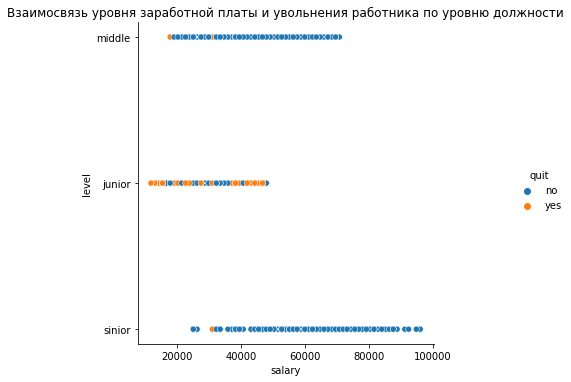

In [72]:
sns.relplot(x='salary', 
            y='level', 
            data=train_quit, 
            kind='scatter', 
           hue='quit')
plt.title('Взаимосвязь уровня заработной платы и увольнения работника по уровню должности');

Причем основная масса уволившихся это низкие позиции;

Более выскоквалифицированные работники, которые уволились, также имели низкую заработную плату относительно своего уровня должностей

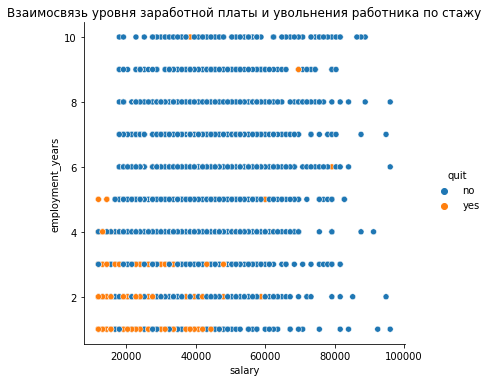

In [73]:
sns.relplot(x='salary', 
            y='employment_years', 
            data=train_quit, 
            kind='scatter', 
           hue='quit')
plt.title('Взаимосвязь уровня заработной платы и увольнения работника по стажу');

увольняются те работники, которые имеют невысокую зарплату в течение трех лет

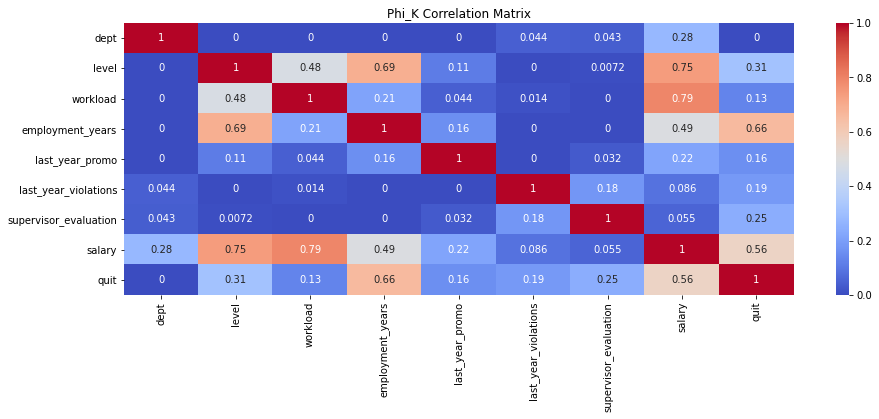

In [74]:
corr_matrix = train_quit.drop(['id'], axis=1).phik_matrix(interval_cols=['salary'])


#визуализация матрицы корреляции 
plt.figure(figsize=(15, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Phi_K Correlation Matrix')
plt.show()

Удаление категорий из-за сильной корреляции не требуется, ситуация очень схожа с нашей первой задачей. Оставим все как есть. 

**Портрет уволившегося:**

* имеет медианный уровень заработной платы ниже, чем у остальных, причем во всех отделах;

* имеет низкий уровень нагрузки;

* занимает невысокую позицию;

* выскоквалифицированные работники, которые уволились, также имели низкую заработную плату относительно своего уровня должности;

* имеет невысокую зарплату в течение трех лет.

## ***Шаг 4. Добавление нового входного признака***

Допустим, job_satisfaction_rate и quit действительно связаны и вы получили необходимое значение метрики в первой задаче. 

Тогда добавьте job_satisfaction_rate, предсказанный лучшей моделью первой задачи, к входным признакам второй задачи.

In [75]:
#добавим job_satisfaction_rate из первой задачи, к входным признакам второй задачи
X_test1['job_satisfaction_rate'] = y_test
X_test1['quit'] = y_test1['quit']
X_test1.head()

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,quit
0,100298,hr,junior,low,2,no,no,4,19200,0.80,no
1,100480,marketing,junior,low,4,no,no,4,16800,0.84,no
2,100503,purchasing,middle,high,5,no,no,4,55200,0.79,no
3,100610,sales,middle,medium,5,no,no,4,43200,0.75,no
4,100692,sales,middle,high,6,no,no,4,48000,0.69,no


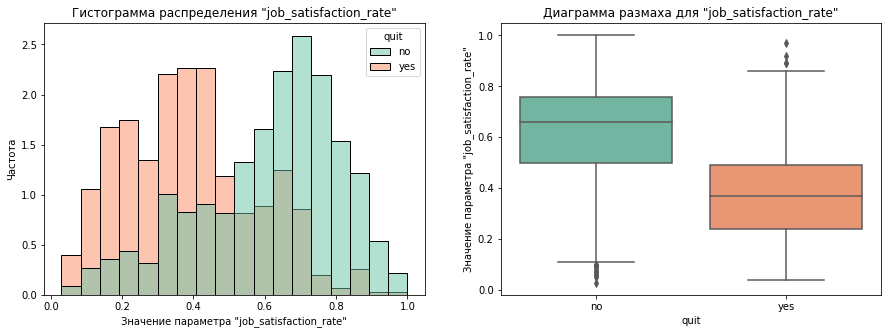

In [76]:
plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
plt.title(f'Гистограмма распределения "job_satisfaction_rate"')
sns.histplot(data=X_test1, x='job_satisfaction_rate', 
             hue='quit', palette='Set2', stat='density', common_norm=False)
plt.xlabel(f'Значение параметра "job_satisfaction_rate"')
plt.ylabel('Частота')
    
plt.subplot(1, 2, 2)
plt.title(f'Диаграмма размаха для "job_satisfaction_rate"')
sns.boxplot(x='quit', y='job_satisfaction_rate', data=X_test1, palette='Set2');
plt.ylabel(f'Значение параметра "job_satisfaction_rate"');

Судя по графикам низкая удовлетверенность и увольнение связаны, однако мы удостоверимся проведя A/B тест не является ли наше предположение случайностью.  

Для этого применим т-тест так как мы имеем распрделения данных похожие на нормальные и являются независимыми. 


Нулевая гипотеза Н0: средние уровни удовлетворенности уволившихся и неуволившихся работников равны.

Альтернативная гипотеза Н1: средние уровни удовлетворенности уволившихся и неуволившихся работников не равны.

In [77]:
alpha = 0.05 #уровень значимости 

#расчет p_value
results = st.ttest_ind(X_test1.query('quit == "no"')['job_satisfaction_rate'], 
                       X_test1.query('quit == "yes"')['job_satisfaction_rate'])

print('Средний уровень удовлетворённости уволившегося сотрудника:', 
      round(X_test1.query('quit == "yes"')['job_satisfaction_rate'].mean(), 2))
print('Средний уровень удовлетворённости оставшегося сотрудника:', 
      round(X_test1.query('quit == "no"')['job_satisfaction_rate'].mean(), 2))
print('p-значение:', results.pvalue)

if results.pvalue < alpha: #проверка p_value
    print('Достаточно основания чтобы отвергнуть нулевую гипотезу')
else:
    print('Недостаточно основания чтобы отвергнуть нулевую гипотезу') 

Средний уровень удовлетворённости уволившегося сотрудника: 0.39
Средний уровень удовлетворённости оставшегося сотрудника: 0.61
p-значение: 1.231122066517193e-104
Достаточно основания чтобы отвергнуть нулевую гипотезу


В результате проведенного А/Б теста мы можем считать что средние уровни удовлетворенности уволившихся и неуволившихся работников не равны, а следовательно как мы видим по результатам визуализации, чем выще уровень удовлетворенности работой, тем меньше шансов что работник уволится. 

## ***Шаг 5. Подготовка данных***
Подготовьте признаки так же, как и в первой задаче: выполните подготовку в пайплайне, дополнив пайплайн предобработки. При кодировании учитывайте особенности признаков и моделей и используйте как минимум два кодировщика.
_____

Эта задача уже будет решаться как задача бинарной классификации

In [78]:
train_quit1 = train_quit.drop('id', axis=1) #создание тренировочной выборки для второй задачи
train_quit1.duplicated().sum() #явные дубли - убираем

1413

In [79]:
train_quit1 = train_quit1.drop_duplicates().reset_index(drop=True)

In [80]:
X_train1 = train_quit1.drop('quit', axis=1)

y = grid.predict(X_train1) #прогноз удовлетворенности для новой тестовой выборки

X_train1['job_satisfaction_rate'] = pd.DataFrame(y) #добавление нового входного признака
X_train1.head(2)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,sales,middle,high,2,no,no,4,54000,0.636670
1,sales,junior,medium,2,no,no,4,27600,0.842677


In [81]:
y_test1.head()

,id,quit
0,100298,no
1,100480,no
2,100503,no
3,100610,no
4,100692,no


In [82]:
y = grid.predict(X_test1) #прогноз

X_test1['job_satisfaction_rate'] = pd.DataFrame(y) #добавление нового входного признака
X_test1.head(2)

/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,quit
0,100298,hr,junior,low,2,no,no,4,19200,0.829985,no
1,100480,marketing,junior,low,4,no,no,4,16800,0.846556,no


In [83]:
# создание тренировочной выборки входных признаков и целевого признака
y_train_1 = train_quit1['quit']
X_test_1 = X_test1.drop(['id', 'quit'], axis=1)
y_test1 = y_test1['quit']

In [84]:
num_col_1 = ['employment_years', 
           'supervisor_evaluation', 
           'salary', 
           'job_satisfaction_rate']

ohe_col_1 = ['dept',
           'level',
           'workload',
           'last_year_promo', 
           'last_year_violations']

ord_col_1 = ['level',
             'workload']

In [85]:
#кодирование целевого признака
label_encoder = LabelEncoder()
y_train_1 = label_encoder.fit_transform(y_train_1)
y_test1 = label_encoder.transform(y_test1)

In [86]:
# Pipeline для кодирования категориальных признаков
ohe_pipe_1 = Pipeline(
    [
        ('simpleImputer_ohe', 
         SimpleImputer(missing_values=np.nan, 
                       strategy='most_frequent')), 
        ('ohe', 
         OneHotEncoder(drop='first', 
                       handle_unknown='error', 
                       sparse_output=False))
    ]
)

#Pipeline для кодирования категориальных ранговых признаков
ord_pipe_1 = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(
                categories=[
                    ['junior', 'middle', 'senior'], 
                    ['low', 'medium', 'high'],
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

# Pipeline для подготовки данных
data_preprocessor_1 = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_col_1),
        ('ord', ord_pipe, ord_col_1),
        ('num', StandardScaler(), num_col_1)
    ], 
    remainder='passthrough'
)

# Итоговый Pipeline: подготовка данных и модель
pipe_final_1 = Pipeline([
    ('preprocessor', data_preprocessor_1),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])


param_distributions_1 = [
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(1, 11),
        'preprocessor__num': [StandardScaler(), MinMaxScaler()]   
    },
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 11),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    {
        'models': [RandomForestClassifier(random_state=RANDOM_STATE)],
        'models__n_estimators': [50, 100, 200],
        'models__max_depth': [None, 10, 20, 30],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    {
        'models': [LogisticRegression(random_state=RANDOM_STATE)],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    }
]

## ***Шаг 6. Обучение модели***
Обучите как минимум три модели. Как минимум для двух из них подберите гиперпараметры. Проверьте качество лучшей модели.

Метрика оценки качества в этой задаче — ROC-AUC. Критерий успеха: ROC-AUC≥0.91 на тестовой выборке. 

Напомним: отбор признаков часто помогает улучшить метрику.

In [87]:
#поиск оптимальной модели с перебором гиперпараметров
grid_1 = GridSearchCV(
    pipe_final_1, 
    param_grid=param_distributions_1, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1, 
)

In [88]:
grid_1.fit(X_train1, y_train_1);

/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/conda/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _che

In [89]:
print('Метрика ROC-AUC для лучшей модели:\n', round(grid_1.best_score_, 2)) 
print('\nЛучшая модель и её параметры:\n\n', grid_1.best_params_) 

Метрика ROC-AUC для лучшей модели:
 0.91

Лучшая модель и её параметры:

 {'models': LogisticRegression(random_state=42), 'preprocessor__num': StandardScaler()}


In [90]:
# Создание DataFrame с результатами кросс-валидации
results_df = pd.DataFrame(grid_1.cv_results_)

# Сортируем результаты по убыванию метрики ROC-AUC
sorted_results = results_df.sort_values(by='mean_test_score', ascending=False)

# Выводим топ-10 лучших моделей
print('Топ-10 моделей по метрике ROC-AUC:')

# Установка опции для отображения максимальной ширины столбца
pd.set_option('display.max_colwidth', None)
display(sorted_results[['params', 'mean_test_score']].head(10))

Топ-10 моделей по метрике ROC-AUC:


,params,mean_test_score
83,"{'models': LogisticRegression(random_state=42), 'preprocessor__num': StandardScaler()}",0.912179
84,"{'models': LogisticRegression(random_state=42), 'preprocessor__num': MinMaxScaler()}",0.910585
63,"{'models': RandomForestClassifier(random_state=42), 'models__max_depth': 10, 'models__n_estimators': 200, 'preprocessor__num': MinMaxScaler()}",0.906494
64,"{'models': RandomForestClassifier(random_state=42), 'models__max_depth': 10, 'models__n_estimators': 200, 'preprocessor__num': 'passthrough'}",0.906455
62,"{'models': RandomForestClassifier(random_state=42), 'models__max_depth': 10, 'models__n_estimators': 200, 'preprocessor__num': StandardScaler()}",0.906391
56,"{'models': RandomForestClassifier(random_state=42), 'models__max_depth': 10, 'models__n_estimators': 50, 'preprocessor__num': StandardScaler()}",0.906348
59,"{'models': RandomForestClassifier(random_state=42), 'models__max_depth': 10, 'models__n_estimators': 100, 'preprocessor__num': StandardScaler()}",0.905955
60,"{'models': RandomForestClassifier(random_state=42), 'models__max_depth': 10, 'models__n_estimators': 100, 'preprocessor__num': MinMaxScaler()}",0.905864
61,"{'models': RandomForestClassifier(random_state=42), 'models__max_depth': 10, 'models__n_estimators': 100, 'preprocessor__num': 'passthrough'}",0.905809
58,"{'models': RandomForestClassifier(random_state=42), 'models__max_depth': 10, 'models__n_estimators': 50, 'preprocessor__num': 'passthrough'}",0.905735


In [91]:
y_pred_1 = grid_1.predict_proba(X_test1)
print(f'Метрика ROC-AUC на тестовой выборке: {round(roc_auc_score(y_test1, y_pred_1[:, 1]), 2)}')

Метрика ROC-AUC на тестовой выборке: 0.92


/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


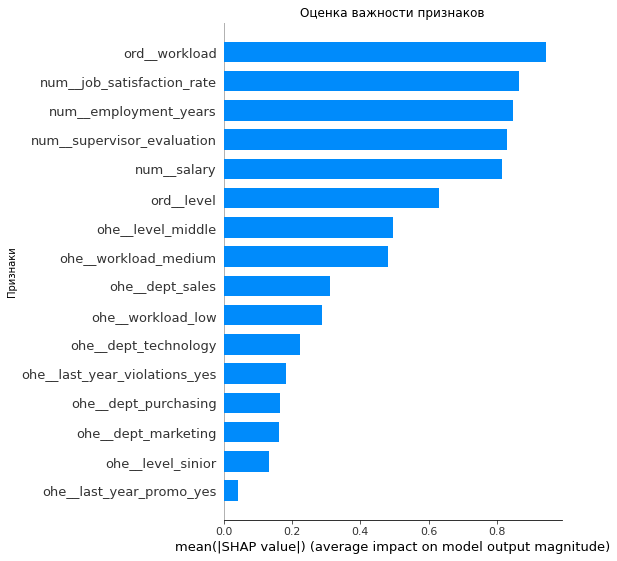

In [92]:
#поиск важных признаков
X_encoded_1 = grid_1.best_estimator_['preprocessor'].fit_transform(X_train1)

model_1 = grid_1.best_estimator_['models'].fit(X_encoded_1, y_train_1)
explainer_1 = shap.PermutationExplainer(model_1, X_encoded_1)


labels_1 = grid_1.best_estimator_[:-1].get_feature_names_out()

plt.title('Оценка важности признаков')
plt.ylabel('Признаки')
shap.summary_plot(X_encoded_1, plot_type='bar', feature_names=labels_1) 

Самый высокий показатель ROC-AUC показала модель логистической регресии с метрикой ROC_AUC = 0.91 (на тренировочной выборке). 

На тестовой выборке  ROC-AUC = 0.92, что соответствует условиям поставленной задачи.

Самым значимым признаком является уровень нагрузки работника.

## ***Шаг 7. Выводы***

* Сделайте промежуточные выводы о том, какая модель справилась лучше и почему.
* Общий вывод
* Сформулируйте общий вывод:
* опишите задачу;
* опишите все этапы работы;
* добавьте выводы и дополнительные предложения для бизнеса.
___________

В ходе проделанной работы мы провели анализ данных работников с целью прогнозирования уровня удовлетворенности работой и прогноза шансов на увольнение работника.

Мы провели предварительную обработку данных, проверили формат колонок и их названия, наличие дубликатов явных и неявных, провели сортировку чтобы соответсвовали идентификационные номера работников между таблицами входных и целевых данных.

Провели исследовательский анализ имеющихся сведений, вызуализировали распределения большей части категорий и выяснили зависимости чтобы понять какие признаки являются "лишними", в итоге мы оставили все колонки так как сильных корреляций не наблюдалось. 

Собрали пайплайн с предобработкой входных признаков (данные кодировались, пустоты заполнялись модой), выбиралась лучшая модель из линейной регрессии, дерева решений и случайного леса. по

По результатам подбора модели и гиперпараметров при решении задачи прогнозирования уровня удовлетворенности:

Лучшей оказалась модель RandomForestRegressor 250 деревьев в ансамбле с глубиной каждого дерева 14. 
C предобработкой MinMaxScaler().

Метрика SMAPE на тестовой выборке: 12.38;

А самым важным признаком оказалсь нагрузка.

Вероятно линейная регрессия не стала лучше по причине наличия нелинейных зависимостей, а дерево решений не дает такой точности как мы получили в моделе случайного леса. Однако, если будет данных еще больше, то текущая модель будет требовать намного больше ресурсов для вычислений.

БЫли замечены закономарности данных и описан портрет работника, который уволилися:

* имеет медианный уровень заработной платы ниже, чем у остальных, причем во всех отделах;
* имеет низкий уровень нагрузки;
* занимает невысокую позицию;
* выскоквалифицированные работники, которые уволились, также имели низкую заработную плату относительно своего уровня должности;
* имеет невысокую зарплату в течение трех лет.

Также мы заметили связь между удовлетворенностью работой и увольнением, подтвержились свою гипотезу проведением статистического теста, в котором равенство удовлетворенности уволенных и работающих оказалось маловероятным и мы удостоверились что сведения о том что удовлеворенность работой и увольнение связаны.  

В связи с этим с использованием первой модели был спрогнозирован уровень удовлетворенности работников новой тренировочной выборке для решения второй задачи, это была уже задача классификации. 

В пайплайн были включены модель ближайщих соседей, дерева решений (именно классификатор), логистической регрессии и метод классификации случаного леса. 

Лучшей оказалась модель классификации случайного леса со значением метрики ROC_AUC 0.92 на тестовой выборке.

Самым значимым признаком оказался уровень нагрузки работника.

_____


Итого, по результатам наблюдений, для удержания работника нужно не тянуть с повышением зарплаты и должности, а также предоставлять средний или высокий уровень нагрузки, так как это по рещультатам наших наблюдений повышает удовлетворенность работой.

<font color='blue'><b>Итоговый комментарий ревьюера</b></font>\
<font color='green'> Алексей, проект принят! \
Все этапы пройдены. Все рекомендации учтены.\
Надеюсь, тебе понравился процесс выполнения и результат.</font> \
<font color='blue'><b>Спасибо, удачи в освоении профессии!</b></font>